## Initial Setup

In [2]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from tqdm import tqdm
import logging
import warnings
import h5py
import random


## wy add
import sys
sys.path.append('../Misc')


# Import custom modules
from data_manage import HDF5ImageGenerator  
from modules import EMA, UNet_conditional_conv   

# Set up matplotlib for inline display
%matplotlib inline

#Suppresses one irrelevant PyTorch warning to not clutter the notebook:

#(Minor security warning that only matteres if we are loading model files from untrusted sources, which is not the case here)
warnings.filterwarnings('ignore', category=FutureWarning, message='You are using `torch.load`.*')



## Essential Setting

In [3]:
config = {
    # Generation Settings
    'num_images': 10,          # How many galaxies to generate
    'use_fixed_seed': False,   # Set True to use specific seed value， fix random seed?
    'seed': None,             # Set to a number to use that specific seed
    'random_redshifts': True,  # True for random redshifts, False for linear spacing  
    
    # Display Settings
    'use_cmap': True,         # True for heatmap, False for grayscale
    'cmap': 'inferno',        # Good options: 'magma', 'inferno', 'viridis', 'hot'
    
    # Quality Control Settings
    'max_std': 0.25,          # Noise filtering threshold； large std: high noise, random pixel values
    'skip_filtering': False,   # Set True to disable noise filtering
    
    # Model Path

    'model_dir': '../Training/Model_Checkpoints_wy',
    # 'model_dir': './Model_Checkpoints',
    'model_name': 'best_model.pth'
}
# Verify model path
model_path = os.path.join(config['model_dir'], config['model_name'])
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model checkpoint not found at: {model_path}")
print(f"Found model checkpoint at: {model_path}")

Found model checkpoint at: ../Training/Model_Checkpoints_wy/best_model.pth


## 🎲 Random Seeds and Image Generation

In [4]:
# Device configuration and initial seed setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Seed handling
if config['use_fixed_seed'] and config['seed'] is not None:
    seed_to_use = config['seed']
    print(f"Using fixed seed: {seed_to_use}")
else:
    seed_to_use = random.randint(0, 1000000)
    print(f"Using random seed: {seed_to_use}")

# Apply the seed to both torch and numpy
torch.manual_seed(seed_to_use)
np.random.seed(seed_to_use)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed_to_use)

Using device: cpu
Using random seed: 79346


## Image Processing

In [5]:
def denormalize_images(images):
    """Converts images from model format (-1 to 1) to viewable format (0 to 1)"""
    return (images + 1) / 2

## The Denoising Diffusion Probabilistic Model

In [6]:
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=64, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)
        self.img_size = img_size
        self.device = device

    def prepare_noise_schedule(self):
        # wy change，change to linearly add noise
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)
    

    # def prepare_noise_schedule(self):
    #     """Prepares a cosine noise schedule for the diffusion process."""
    #     steps = torch.linspace(0, self.noise_steps, self.noise_steps)
    #     schedule = torch.cos((steps / self.noise_steps) * (torch.pi / 2))
    #     beta = self.beta_start + (self.beta_end - self.beta_start) * (1 - schedule)
    #     return beta

    def sample_images(self, model, n, labels):
        """Generates n galaxy images based on given redshift labels with a progress bar."""
        model.eval()
        with torch.no_grad():
            # Initialize starting noise for the images
            x = torch.randn((n, 5, self.img_size, self.img_size)).to(self.device)
            
            # Ensure labels are shaped correctly
            labels = labels.view(-1, 1) if labels.dim() == 1 else labels
            
            # Progress bar for the diffusion process
            for i in tqdm(reversed(range(1, self.noise_steps)), desc="Generating Images", total=self.noise_steps):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t, labels)
                
                # Calculate alphas and betas for the diffusion step
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                
                # Sample noise at each step, except for the last step
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                
                # Update x with predicted noise and diffusion process adjustments
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise) + torch.sqrt(beta) * noise

        model.train()
        return x

## 🔍 Image Quality Control

In [7]:
def filter_and_replace_noisy_images(images, max_std=0.25, skip_filtering=False):
    """
    Removes overly noisy images and replaces them with good ones.
    
    Args:
        images: Image tensor to filter
        max_std: Maximum standard deviation threshold (default: from config or 0.25)
        skip_filtering: If True, returns images unfiltered (default: from config or False)
    """
    if skip_filtering:
        return images
    
    good_images = [img for img in images if img.std().item() < max_std]
    while len(good_images) < images.size(0):
        good_images.extend(good_images)
    good_images = good_images[:images.size(0)]
    return torch.stack(good_images)

def plot_all_channels(images, num_images, max_std=None, cmap=None, use_cmap=None, skip_filtering=None, redshifts=None):
    """
    Plots all 5 channels (g, r, i, z, y) with option for colormap or grayscale.
    
    Args:
        images: Image tensor of shape (N, 5, H, W)
        num_images: Number of images to display
        max_std: Maximum standard deviation for noise filtering (default: from config)
        cmap: Colormap to use (default: from config)
        use_cmap: If True, uses colormap (default: from config)
        skip_filtering: If True, disables noise filtering (default: from config)
        redshifts: Tensor of redshift values for each image
    """
    # Use config settings if not explicitly provided
    max_std = config['max_std'] if max_std is None else max_std
    cmap = config['cmap'] if cmap is None else cmap
    use_cmap = config['use_cmap'] if use_cmap is None else use_cmap
    skip_filtering = config['skip_filtering'] if skip_filtering is None else skip_filtering
    
    # Filter images if enabled
    images = filter_and_replace_noisy_images(images, max_std, skip_filtering)
    num_images = min(num_images, images.size(0))
    num_channels = images.size(1)
    
    # Create figure and grid
    fig = plt.figure(figsize=(num_images * 3, num_channels * 2.5))
    gs = fig.add_gridspec(num_channels, num_images, left=0.015, right=0.98, 
                         top=0.95, bottom=0.05, wspace=0.1, hspace=0.1)
    
    axs = [[fig.add_subplot(gs[i, j]) for j in range(num_images)] for i in range(num_channels)]
    channel_names = ['g', 'r', 'i', 'z', 'y']
    
    # Plot each channel
    for channel_idx in range(num_channels):
        for img_idx in range(num_images):
            channel_data = images[img_idx, channel_idx].cpu().numpy()
            
            # Safe normalization
            channel_min = channel_data.min()
            channel_max = channel_data.max()
            if channel_max - channel_min > 1e-10:  # Check if range is non-zero
                channel_data = (channel_data - channel_min) / (channel_max - channel_min)
            else:
                channel_data = np.full_like(channel_data, 0.5)
            
            axs[channel_idx][img_idx].imshow(channel_data, 
                                           cmap=cmap if use_cmap else 'gray')
            axs[channel_idx][img_idx].axis('off')
            
            if channel_idx == 0:
                if redshifts is not None:
                    title = f"redshift = {redshifts[img_idx].item():.2f}"
                else:
                    title = f"Image {img_idx + 1}"
                axs[channel_idx][img_idx].set_title(title)
            
            if img_idx == 0:
                fig.text(0.01, 0.85 - (channel_idx * 0.195), channel_names[channel_idx], 
                        ha='left', va='center', fontsize=14, fontweight='bold')
    plt.show()

def plot_rgb_channels(images, num_images, max_std=None, skip_filtering=None, redshifts=None):
    """
    Plots images using g, r, i channels combined into RGB display.
    
    Args:
        images: Image tensor of shape (N, 5, H, W)
        num_images: Number of images to display
        max_std: Maximum standard deviation for filtering (default: from config)
        skip_filtering: If True, skips filtering (default: from config)
        redshifts: Tensor of redshift values for each image
    """
    # Use config settings if not explicitly provided
    max_std = config['max_std'] if max_std is None else max_std
    skip_filtering = config['skip_filtering'] if skip_filtering is None else skip_filtering
    
    # Filter images if enabled
    images = filter_and_replace_noisy_images(images, max_std, skip_filtering)
    num_images = min(num_images, images.size(0))
    
    # Calculate grid layout
    rows = (num_images // 6) + (1 if num_images % 6 else 0)
    fig, axs = plt.subplots(rows, 6, figsize=(16, rows * 4))
    axs = axs.flatten()
    
    for idx, ax in enumerate(axs):
        if idx >= num_images:
            ax.axis('off')
            continue
        
        # Combine g, r, i channels into RGB
        rgb_image = torch.stack([
            images[idx, 0],  # g -> Red channel
            images[idx, 1],  # r -> Green channel
            images[idx, 2]   # i -> Blue channel
        ], dim=0)
        
        # Normalize and convert to numpy
        rgb_image = rgb_image.permute(1, 2, 0).cpu().numpy()
        
        # Safe normalization for RGB image
        img_min = rgb_image.min()
        img_max = rgb_image.max()
        if img_max - img_min > 1e-10:  # Check if range is non-zero
            rgb_image = (rgb_image - img_min) / (img_max - img_min)
        else:
            rgb_image = np.full_like(rgb_image, 0.5)
        
        # Plot
        ax.imshow(rgb_image)
        ax.axis('off')
        
        if redshifts is not None:
            title = f"redshift = {redshifts[idx].item():.2f}"
        else:
            title = f"Image #{idx+1}"
        ax.set_title(title)
    
    plt.tight_layout()
    plt.show()

## 🛠️ Model Configuration

In [8]:
class Args:
    def __init__(self):
        self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
        self.image_size = 64    # Size of generated images
        self.noise_steps = 1000  # Steps in diffusion process
        self.beta_start = 1e-4   # Starting noise level
        self.beta_end = 0.02     # Ending noise level

args = Args()

In [9]:
# Initialize model first
model = UNet_conditional_conv(
    c_in=5,  # g,r,i,z,y channels
    c_out=5,
    time_dim=256,
    y_dim=1  # For redshift conditioning
).to(args.device)

# Load the checkpoint and extract model state dict
checkpoint = torch.load(model_path, map_location=args.device, weights_only=False)
#checkpoint = torch.load(model_path, map_location=args.device)
model.load_state_dict(checkpoint['model_state_dict'])   

# Initialize EMA
ema = EMA(model, beta=0.995)
# Load EMA state if it exists in checkpoint
if 'ema_state_dict' in checkpoint:
    ema.load_state_dict(checkpoint['ema_state_dict'])

## Galaxy Generation

In [10]:
# Initialize the diffusion process with specified noise settings
diffusion = Diffusion(
    noise_steps=args.noise_steps,
    beta_start=args.beta_start,
    beta_end=args.beta_end,
    img_size=args.image_size,
    device=args.device
)

# Define the redshift range for the images
redshift_min, redshift_max = 0.1, .5  # Modify these values to change galaxy properties
print(f"\nGenerating galaxies in redshift range: {redshift_min} to {redshift_max}")

# Create redshift values for conditioning based on config setting
if config['random_redshifts']:
    sample_redshifts = torch.rand(config['num_images'], 1).to(device) * (redshift_max - redshift_min) + redshift_min
    print(f"Generating {config['num_images']} galaxies with random redshifts...")
else:
    sample_redshifts = torch.linspace(redshift_min, redshift_max, config['num_images']).to(device).unsqueeze(1)
    print(f"Generating {config['num_images']} galaxies with linearly spaced redshifts...")

# Generate images with progress bar
with torch.no_grad():
    ema_model = ema.get_ema_model()
    generated_images = diffusion.sample_images(ema_model, config['num_images'], sample_redshifts)
print(f"Generated images shape: {generated_images.shape}")


Generating galaxies in redshift range: 0.1 to 0.5
Generating 10 galaxies with random redshifts...


Generating Images: 100%|█████████▉| 999/1000 [05:09<00:00,  3.23it/s]

Generated images shape: torch.Size([10, 5, 64, 64])


## 📊 Visualization and Analysis

Generated images shape: torch.Size([10, 5, 64, 64])

🎨 RGB Composite View (g, r, i channels combined) - Generated Images:


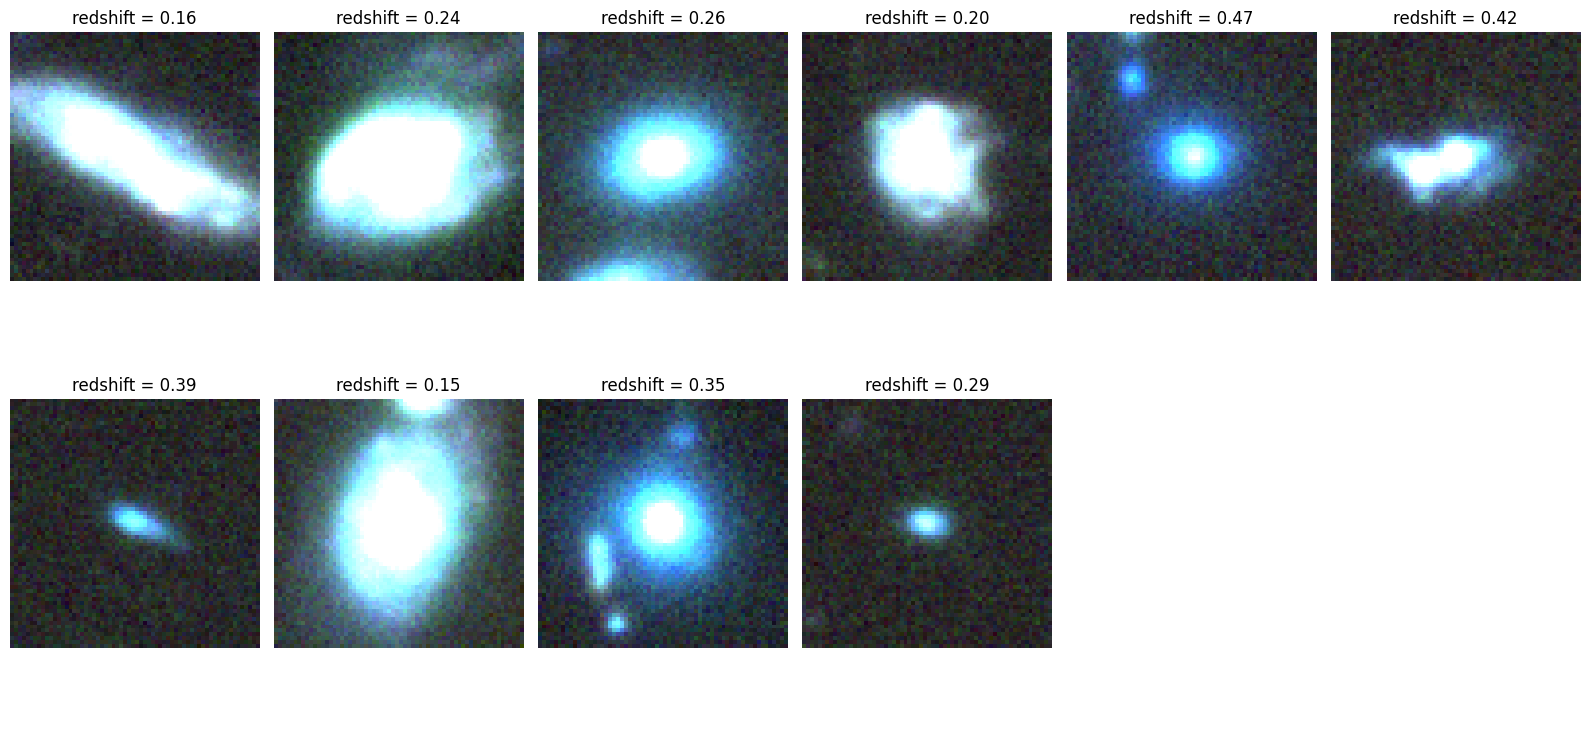


📊 Individual Channel View (g, r, i, z, y separately) - Generated Images:


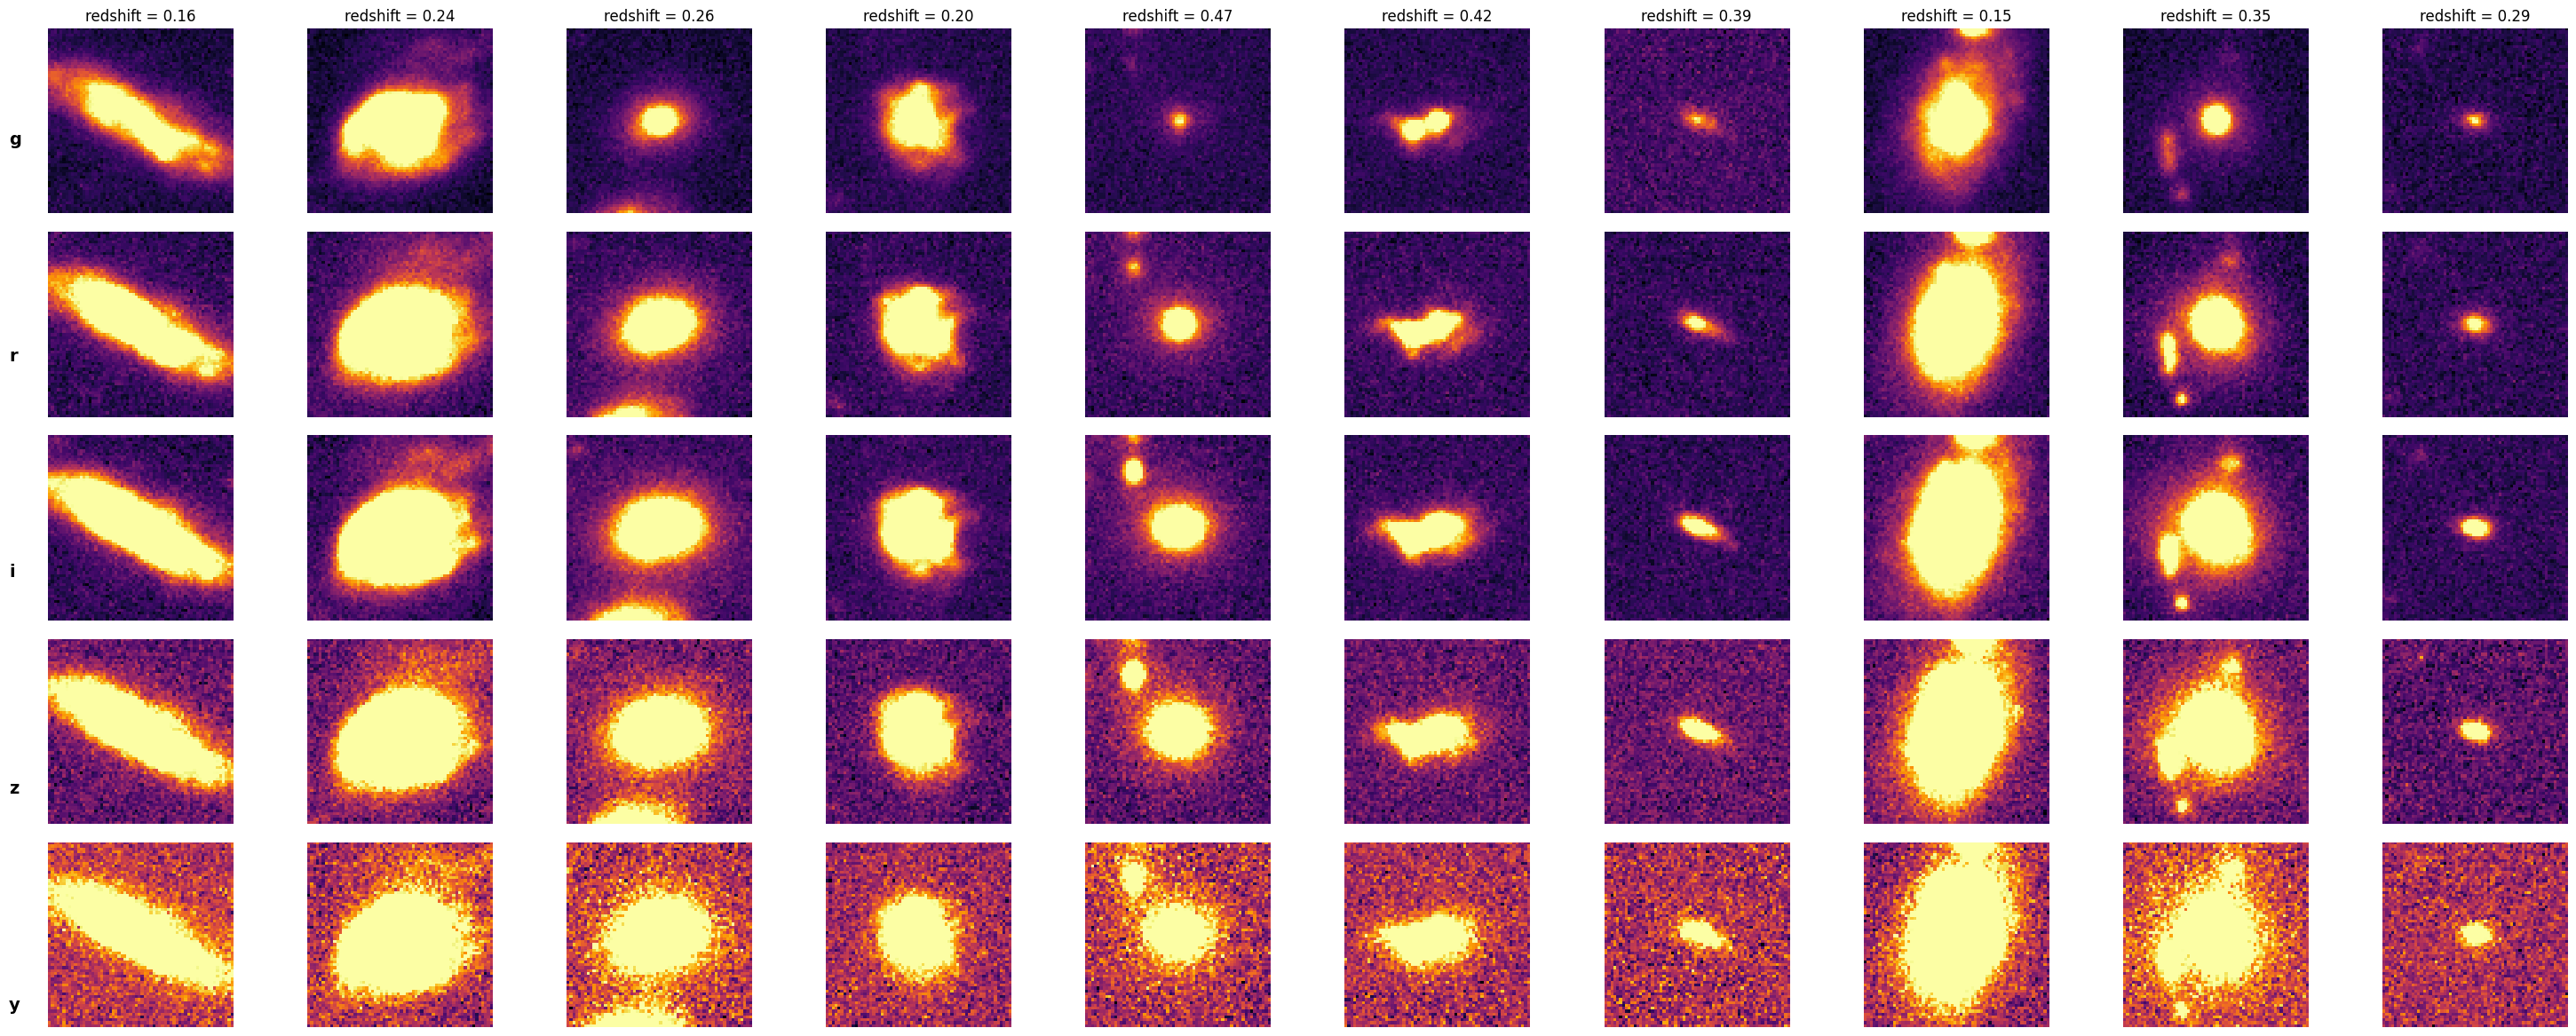


📊 Image Statistics - Generated Images:
Mean intensity: 0.6259
Standard deviation: 0.1772
Redshift range: 0.15 to 0.47

 Generation Settings:
  • Random Seed: 79346 (Random)
  • Redshift Distribution: Random
  • Redshift Range: 0.1 to 0.5

Display Settings:
  • Mode: Heatmap
  • Colormap: inferno

Quality Control:
  • Noise Filtering: Enabled
  • Filter Threshold: 0.25 (lower = stricter)

💡 Tip: Adjust these settings in the config section at the top of the notebook


In [11]:
print(f"Generated images shape: {generated_images.shape}")

# Prepare images for display
generated_images_denorm = denormalize_images(generated_images)
generated_images_denorm = torch.clamp(generated_images_denorm, 0.0, 1.0)

# Display RGB composite view
print("\n🎨 RGB Composite View (g, r, i channels combined) - Generated Images:")
plot_rgb_channels(
    images=generated_images_denorm,
    num_images=config['num_images'],
    max_std=config['max_std'],
    skip_filtering=config['skip_filtering'],
    redshifts=sample_redshifts   
)

# Display individual channel view
print("\n📊 Individual Channel View (g, r, i, z, y separately) - Generated Images:")
plot_all_channels(
    images=generated_images_denorm,
    num_images=config['num_images'],
    max_std=config['max_std'],
    cmap=config['cmap'],
    use_cmap=config['use_cmap'],
    skip_filtering=config['skip_filtering'],
    redshifts=sample_redshifts   
)

# Display statistics and settings
print("\n📊 Image Statistics - Generated Images:")
print(f"Mean intensity: {generated_images_denorm.mean().item():.4f}")
print(f"Standard deviation: {generated_images_denorm.std().item():.4f}")
print(f"Redshift range: {sample_redshifts.min().item():.2f} to {sample_redshifts.max().item():.2f}")

print("\n Generation Settings:")
print(f"  • Random Seed: {seed_to_use} ({'Fixed' if config['use_fixed_seed'] else 'Random'})")
print(f"  • Redshift Distribution: {'Random' if config['random_redshifts'] else 'Linear'}")
print(f"  • Redshift Range: {redshift_min} to {redshift_max}")

print("\nDisplay Settings:")
print(f"  • Mode: {'Heatmap' if config['use_cmap'] else 'Grayscale'}")
print(f"  • Colormap: {config['cmap'] if config['use_cmap'] else 'N/A'}")

print("\nQuality Control:")
print(f"  • Noise Filtering: {'Disabled' if config['skip_filtering'] else 'Enabled'}")
print(f"  • Filter Threshold: {config['max_std']} (lower = stricter)")

print("\n💡 Tip: Adjust these settings in the config section at the top of the notebook")

## 📊 Visualize Real Images For Comparison

In [12]:
def load_real_images(hdf5_path, num_images, redshift_min=None, redshift_max=None, random_redshifts=True, seed_to_use=None):
    """
    Load real images from HDF5 file with optional redshift filtering.
    """
    # Generate a completely new random seed for this specific selection
    selection_seed = random.randint(0, 1000000)
    np.random.seed(selection_seed)
     
    
    with h5py.File(hdf5_path, 'r') as f:
        total_images = f['image'].shape[0]
        all_redshifts = f['specz_redshift'][:]
        
        # Filter by redshift range
        valid_indices = np.where((all_redshifts >= redshift_min) & 
                               (all_redshifts <= redshift_max))[0]
        
        if len(valid_indices) == 0:
            raise ValueError(f"No images found in redshift range {redshift_min} to {redshift_max}")
        
        # Select images
        if random_redshifts:
            print("Using random selection")
            selected_indices = np.random.permutation(valid_indices)[:num_images]
        else:
            print("Using linear spacing with random selection at each redshift")
            target_redshifts = np.linspace(redshift_min, redshift_max, num_images)
            selected_indices = []
            
            for target_z in target_redshifts:
                # Find all images near this redshift
                redshift_diffs = np.abs(all_redshifts[valid_indices] - target_z)
                # Get the indices of the 10 closest matches
                closest_matches = np.argsort(redshift_diffs)[:10]  # Take 10 closest matches
                # Randomly select one from these matches
                selected_idx = valid_indices[closest_matches[np.random.randint(0, len(closest_matches))]]
                selected_indices.append(selected_idx)
            
            selected_indices = np.array(selected_indices)
        
        # Sort indices for HDF5 access
        sorted_idx = np.argsort(selected_indices)
        sorted_selected_indices = selected_indices[sorted_idx]
        
        # Load images and redshifts
        selected_images = f['image'][sorted_selected_indices]
        selected_redshifts = f['specz_redshift'][sorted_selected_indices]
        
        # Restore original order
        selected_images = selected_images[np.argsort(sorted_idx)]
        selected_redshifts = selected_redshifts[np.argsort(sorted_idx)]
        
        # Reset random seed to original value if one was provided
        if seed_to_use is not None:
            np.random.seed(seed_to_use)
            
        return torch.tensor(selected_images), torch.tensor(selected_redshifts)


Loading real galaxies in redshift range: 0.1 to 0.5
Using random selection

🎨 RGB Composite View (g, r, i channels combined) - Real Images:


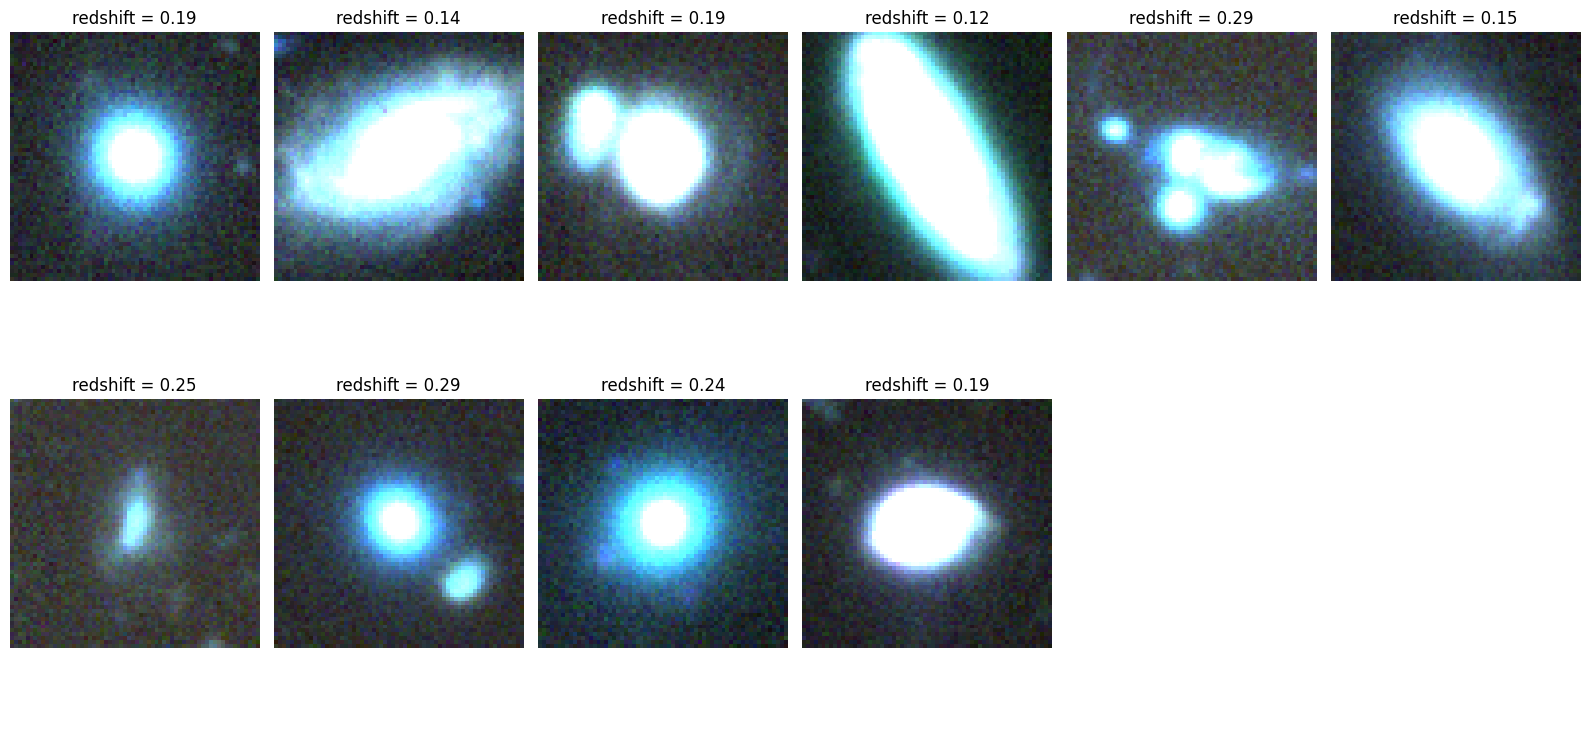


📊 Individual Channel View (g, r, i, z, y separately) - Real Images:


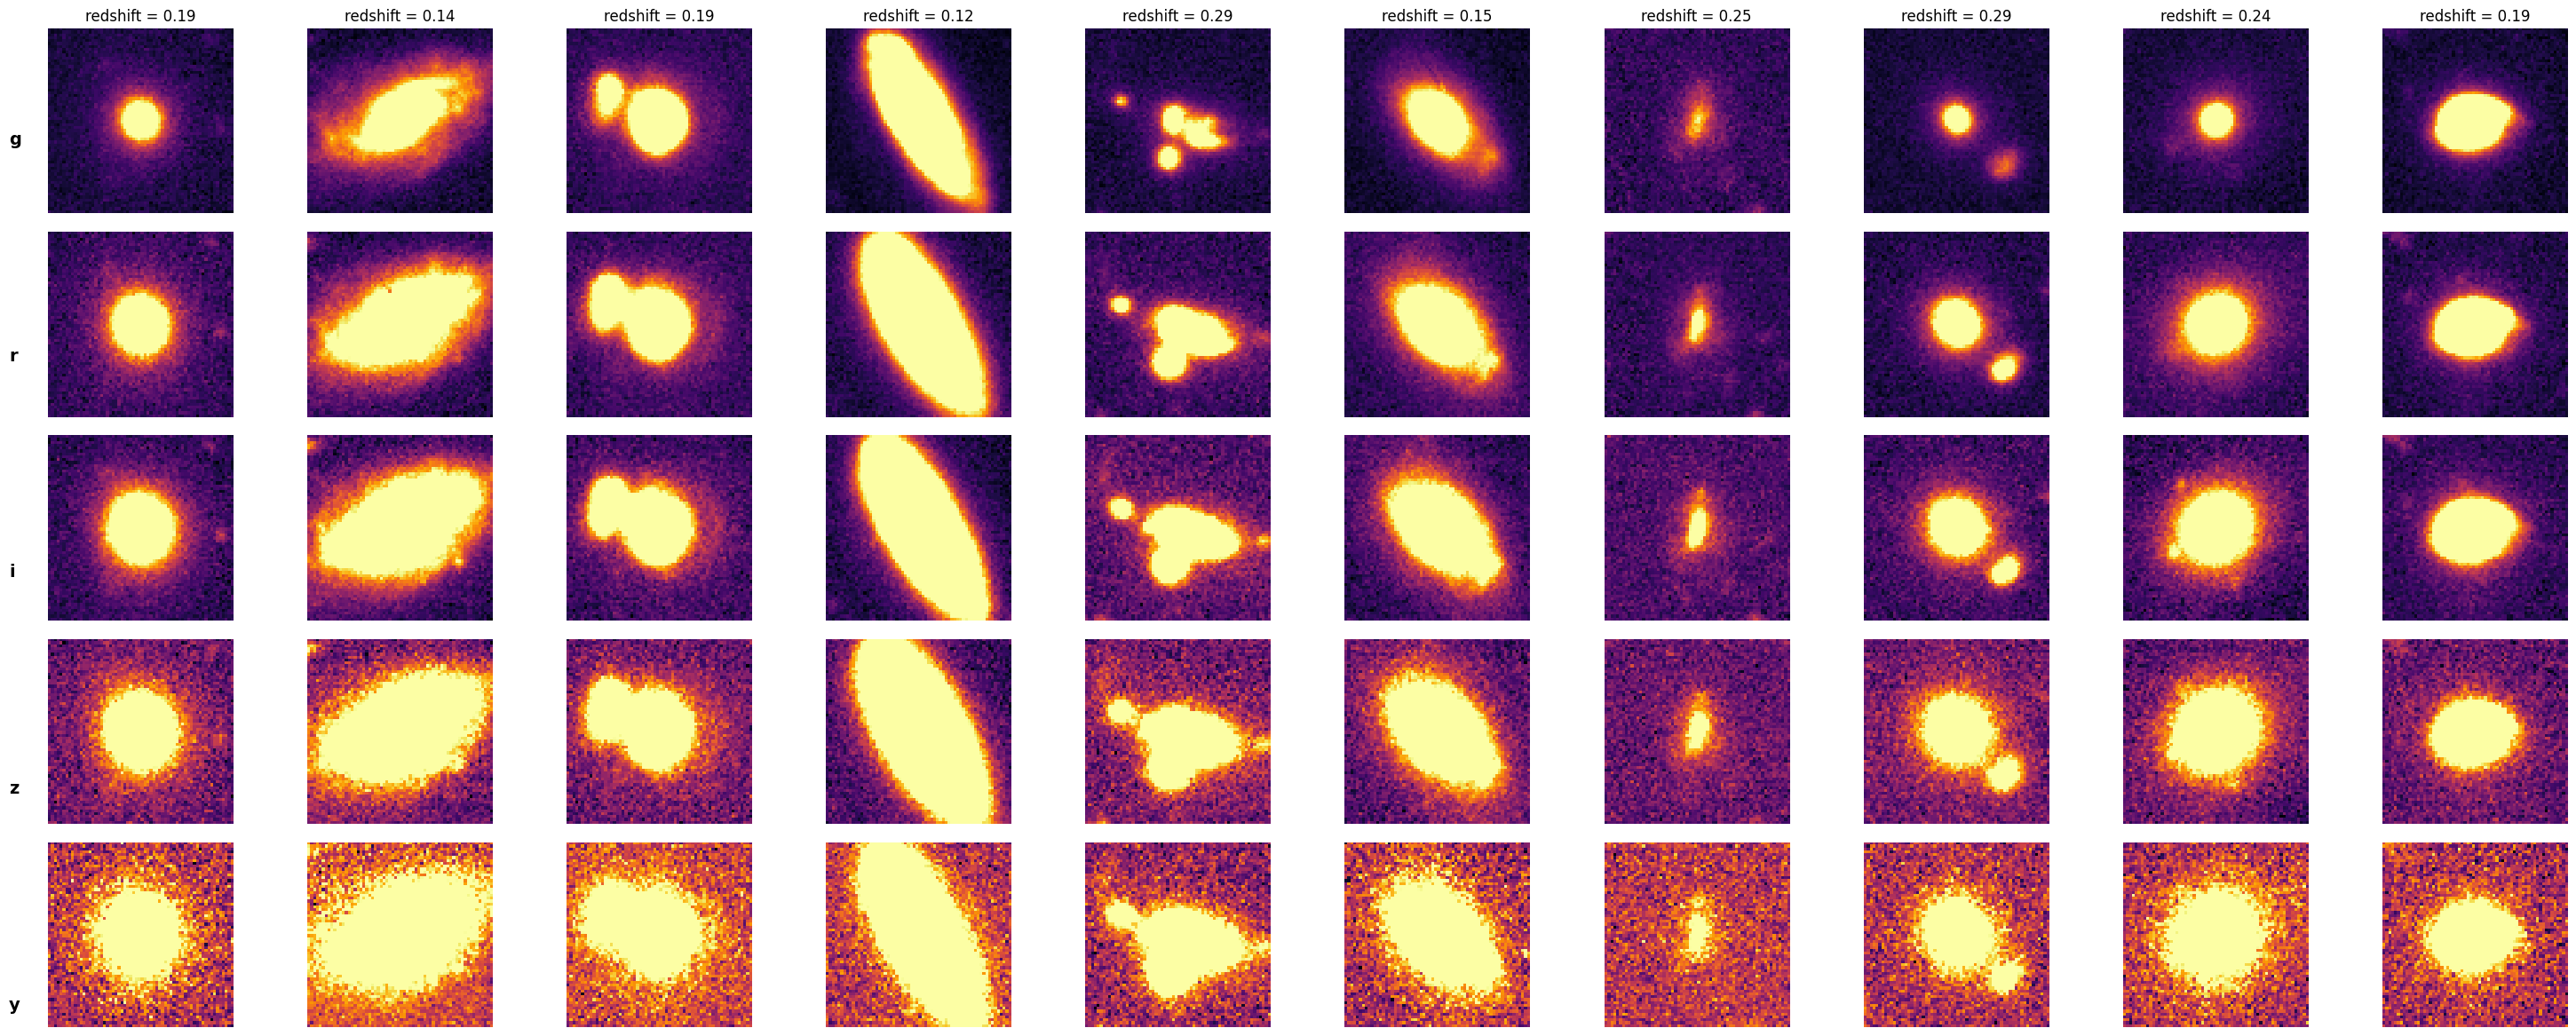


📊 Image Statistics - Real Images:
Mean intensity: 0.6578
Standard deviation: 0.1877
Redshift range: 0.12 to 0.29

 Current Settings for Real Images:
  • Redshift Distribution: Random
  • Redshift Range: 0.1 to 0.5

Display Settings:
  • Mode: Heatmap
  • Colormap: inferno

Quality Control:
  • Noise Filtering: Enabled
  • Filter Threshold: 0.25 (lower = stricter)


In [13]:
# Define the path to the testing HDF5 file
testing_hdf5_path = '/Users/wen/Desktop/project/archive/5x64x64_testing_with_morphology.hdf5'
#testing_hdf5_path = '/shared/astrodata/5x64x64_testing_with_morphology.hdf5'

# Define redshift range (similar to generated images)
redshift_min, redshift_max = 0.1, .5

print(f"\nLoading real galaxies in redshift range: {redshift_min} to {redshift_max}")

try:
    real_images_tensor, real_redshifts = load_real_images(
        testing_hdf5_path,
        config['num_images'],
        redshift_min=redshift_min,
        redshift_max=redshift_max,
        random_redshifts=config['random_redshifts'],
        seed_to_use=seed_to_use
    )
    
    # Normalize the real images for display
    real_images_denorm = denormalize_images(real_images_tensor)
    real_images_denorm = torch.clamp(real_images_denorm, 0.0, 1.0)

    # Display RGB composite view for real images
    print("\n🎨 RGB Composite View (g, r, i channels combined) - Real Images:")
    plot_rgb_channels(
        images=real_images_denorm,
        num_images=config['num_images'],
        max_std=config['max_std'],
        skip_filtering=config['skip_filtering'],
        redshifts=real_redshifts
    )

    # Display individual channel view for real images
    print("\n📊 Individual Channel View (g, r, i, z, y separately) - Real Images:")
    plot_all_channels(
        images=real_images_denorm,
        num_images=config['num_images'],
        max_std=config['max_std'],
        cmap=config['cmap'],
        use_cmap=config['use_cmap'],
        skip_filtering=config['skip_filtering'],
        redshifts=real_redshifts
    )

    # Display statistics and settings for real images
    print("\n📊 Image Statistics - Real Images:")
    print(f"Mean intensity: {real_images_denorm.mean().item():.4f}")
    print(f"Standard deviation: {real_images_denorm.std().item():.4f}")
    print(f"Redshift range: {real_redshifts.min().item():.2f} to {real_redshifts.max().item():.2f}")
    
    print("\n Current Settings for Real Images:")
    print(f"  • Redshift Distribution: {'Random' if config['random_redshifts'] else 'Linear'}")
    print(f"  • Redshift Range: {redshift_min} to {redshift_max}")
    print("\nDisplay Settings:")
    print(f"  • Mode: {'Heatmap' if config['use_cmap'] else 'Grayscale'}")
    print(f"  • Colormap: {config['cmap'] if config['use_cmap'] else 'N/A'}")
    print("\nQuality Control:")
    print(f"  • Noise Filtering: {'Disabled' if config['skip_filtering'] else 'Enabled'}")
    print(f"  • Filter Threshold: {config['max_std']} (lower = stricter)")
    
except ValueError as e:
    print(f"Error: {e}")
    print("Please try a different redshift range.")